# Text Analytics

## Sentiment Classification

### Loading the dataset

In [44]:
import pandas as pd
import numpy as np
import csv


import warnings
warnings.filterwarnings('ignore')

train_ds = pd.read_csv( "sentiment_train",
                        delimiter="\t",
                        quoting=csv.QUOTE_NONE,
                        engine="python" )
train_ds.head( 5 )

,sentiment,text
0,1,The Da Vinci Code book is just awesome.
1,1,"this was the first clive cussler i've ever read, but even books like Relic, and Da Vinci code were more plausible than this."
2,1,i liked the Da Vinci Code a lot.
3,1,i liked the Da Vinci Code a lot.
4,1,I liked the Da Vinci Code but it ultimately didn't seem to hold it's own.


In [2]:
pd.set_option('max_colwidth', 800)
train_ds[train_ds.sentiment == 1][0:5]

,sentiment,text
0,1,The Da Vinci Code book is just awesome.
1,1,"this was the first clive cussler i've ever read, but even books like Relic, and Da Vinci code were more plausible than this."
2,1,i liked the Da Vinci Code a lot.
3,1,i liked the Da Vinci Code a lot.
4,1,I liked the Da Vinci Code but it ultimately didn't seem to hold it's own.


In [3]:
train_ds[train_ds.sentiment == 0][0:5]

,sentiment,text
3943,0,da vinci code was a terrible movie.
3944,0,"Then again, the Da Vinci code is super shitty movie, and it made like 700 million."
3945,0,"The Da Vinci Code comes out tomorrow, which sucks."
3946,0,i thought the da vinci code movie was really boring.
3947,0,"God, Yahoo Games has this truly-awful looking Da Vinci Code-themed skin on it's chessboard right now."


### Exploring the dataset

In [43]:
train_ds.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7086 entries, 0 to 7085
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  7086 non-null   int64 
 1   text       7086 non-null   object
dtypes: int64(1), object(1)
memory usage: 110.8+ KB


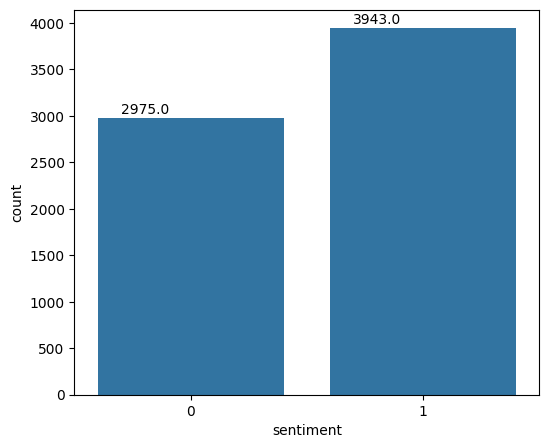

In [5]:
import matplotlib.pyplot as plt
import seaborn as sn

plt.figure( figsize=(6,5))
# create count plot
ax = sn.countplot(x='sentiment', data=train_ds)
# annotate
for p in ax.patches:
        ax.annotate(p.get_height(), (p.get_x()+0.1, p.get_height()+50))

### Text Preprocessing

#### Creating Count Vectors for *sentiment_train* dataset

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize the CountVectorizer
count_vectorizer = CountVectorizer()
# Create the dictionary from the corpus
feature_vector = count_vectorizer.fit( train_ds.text )
# Get the feature names
features = list(feature_vector.get_feature_names_out())
print( "Total number of features: ", len(features))

Total number of features:  2132


In [7]:
import random

random.sample(features, 10)

['jon',
 'grown',
 'xd',
 'lame',
 'spanish',
 'big',
 'glad',
 'scenes',
 'characterization',
 'station']

In [8]:
train_ds_features = count_vectorizer.transform( train_ds.text )
type(train_ds_features)

scipy.sparse._csr.csr_matrix

In [9]:
train_ds_features.shape

(6918, 2132)

In [ ]:
train_ds_features.getnnz()

In [ ]:
print( "Density of the matrix: ",
      train_ds_features.getnnz() * 100 /
      (train_ds_features.shape[0] * train_ds_features.shape[1]))

#### Displaying Document Vectors

In [10]:
# Converting the matrix to a dataframe
train_ds_df = pd.DataFrame(train_ds_features.todense())
# Setting the column names to the features i.e. words
train_ds_df.columns = features

In [11]:
train_ds[0:1]

,sentiment,text
0,1,The Da Vinci Code book is just awesome.


In [12]:
train_ds_df.iloc[0:1, 150:157]

,away,awesome,awesomely,awesomeness,awesomest,awful,awkward
0,0,1,0,0,0,0,0


In [13]:
train_ds_df[['the', 'da', "vinci", "code", "book", 'is', 'just', 'awesome']][0:1]

,the,da,vinci,code,book,is,just,awesome
0,1,1,1,1,1,1,1,1


####  Removing low frequency words

In [14]:
# summing up the occurrences of features column wise
features_counts = np.sum( train_ds_features.toarray(), axis = 0 )
feature_counts_df = pd.DataFrame( dict( features = features,
                                    counts = features_counts ) )

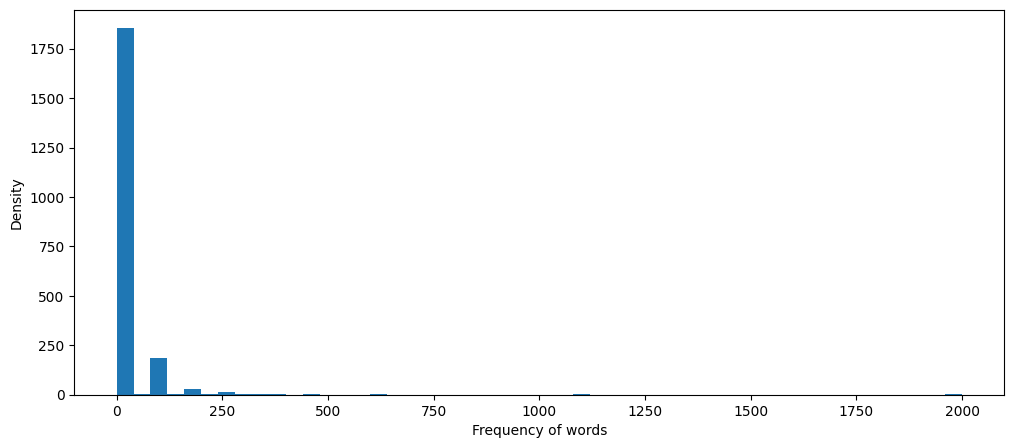

In [15]:
plt.figure( figsize=(12,5))
plt.hist(feature_counts_df.counts, bins=50, range = (0, 2000));
plt.xlabel( 'Frequency of words' )
plt.ylabel( 'Density' );

In [16]:
len(feature_counts_df[feature_counts_df.counts == 1])

1228

In [19]:
# Initialize the CountVectorizer
count_vectorizer = CountVectorizer(min_df = 5,
                                   max_df = 0.7)
# Create the dictionary from the corpus
feature_vector = count_vectorizer.fit( train_ds.text )
# Get the feature names
features = list(feature_vector.get_feature_names_out())
# Transform the document into vectors
train_ds_features = count_vectorizer.transform( train_ds.text )
# Count the frequency of the features
features_counts = np.sum( train_ds_features.toarray(), axis = 0 )
feature_counts = pd.DataFrame( dict( features = features,
                                    counts = features_counts ) )

In [21]:
feature_counts.sort_values('counts',
                           ascending = True)[0:15]

,features,counts
434,yes,5
18,angels,5
22,apparently,5
394,until,5
337,song,5
363,theater,5
380,through,5
397,used,5
292,probably,5
265,novel,5


In [22]:
feature_counts.shape

(439, 2)

#### Removing Stop Words

In [23]:
from sklearn.feature_extraction import text

my_stop_words = text.ENGLISH_STOP_WORDS

#Printing first few stop words
print("Few stop words: ", list(my_stop_words)[0:10])

Few stop words:  ['amongst', 'neither', 'put', 'a', 'nowhere', 'otherwise', 'nine', 'ie', 'often', 'six']


In [24]:
# Adding custom words to the list of stop words
my_stop_words = list(text.ENGLISH_STOP_WORDS.union( ['harry', 'potter', 'code', 'vinci', 'da',
                                                'harry', 'mountain', 'movie', 'movies']))

#### Creating Count Vectors

In [25]:
# Setting stop words list
count_vectorizer = CountVectorizer( stop_words = my_stop_words,
                                    min_df = 5,
                                    max_df = 0.7)

feature_vector = count_vectorizer.fit( train_ds.text )
train_ds_features = count_vectorizer.transform( train_ds.text )
features = list(feature_vector.get_feature_names_out())
features_counts = np.sum( train_ds_features.toarray(), axis = 0 )
feature_counts = pd.DataFrame( dict( features = features,
                                    counts = features_counts ) )

In [26]:
feature_counts.sort_values( "counts", ascending = False )[0:15]

,features,counts
30,brokeback,2000
161,love,1624
11,awesome,1127
175,mission,1094
128,impossible,1093
150,like,974
244,sucks,602
243,sucked,600
109,hate,578
208,really,374


In [45]:
from nltk.stem.snowball import PorterStemmer

stemmer = PorterStemmer()
analyzer = CountVectorizer().build_analyzer()

#Custom function for stemming and stop word removal

def stemmed_words(doc):
    # Tokenize using the analyzer
    words = analyzer(doc)

    # Remove stop words first
    non_stop_words = [w for w in words if w not in my_stop_words]

    # Apply stemming
    stemmed_words = [stemmer.stem(w) for w in non_stop_words]

    return stemmed_words

In [46]:
count_vectorizer = CountVectorizer( analyzer=stemmed_words,
                                    min_df = 5,
                                    max_df = 0.7)

feature_vector = count_vectorizer.fit( train_ds.text )
train_ds_features = count_vectorizer.transform( train_ds.text )
features = list(feature_vector.get_feature_names_out())
features_counts = np.sum( train_ds_features.toarray(), axis = 0 )
feature_counts = pd.DataFrame( dict( features = features,
                                    counts = features_counts ) )
feature_counts.sort_values( "counts", ascending = False )[0:15]

,features,counts
30,brokeback,2000
168,love,1883
248,suck,1484
158,like,1155
13,awesom,1130
180,mission,1094
135,imposs,1093
116,hate,701
214,realli,374
247,stupid,365


In [47]:
feature_counts.shape

(297, 2)

#### Distribution of words across different sentiment

In [48]:
# Convert the document vector matrix into dataframe
train_ds_df = pd.DataFrame(train_ds_features.todense())
# Assign the features names to the column
train_ds_df.columns = features
# Assign the sentiment labels to the train_ds
train_ds_df['sentiment'] = train_ds.sentiment

In [49]:
train_ds_features.shape

(7086, 297)

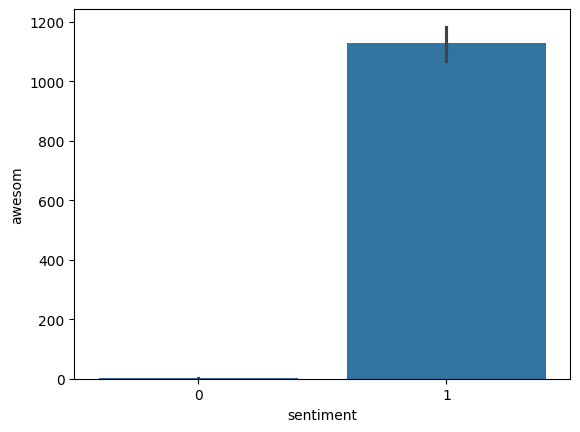

In [50]:
sn.barplot( x = 'sentiment', y = 'awesom', data = train_ds_df, estimator=sum );

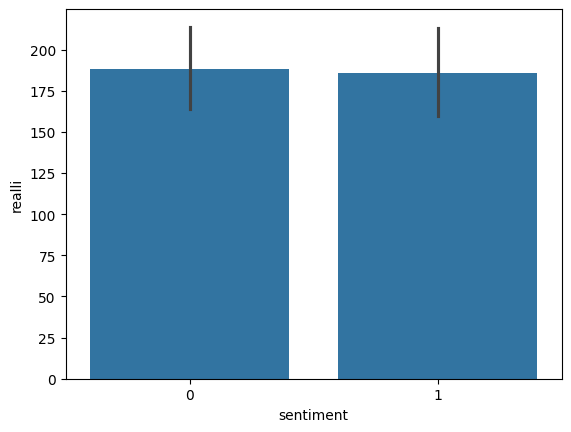

In [51]:
sn.barplot( x = 'sentiment', y = 'realli', data = train_ds_df, estimator=sum );

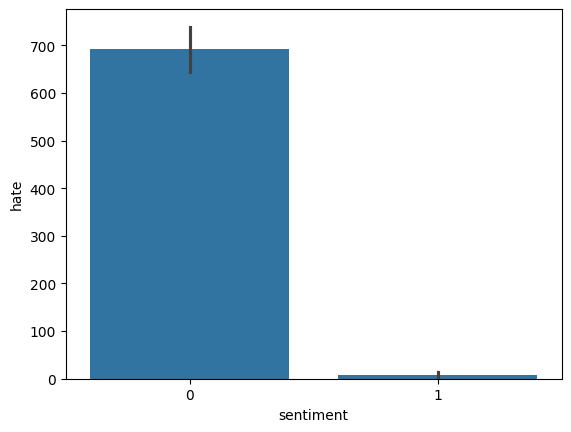

In [52]:
sn.barplot( x = 'sentiment', y = 'hate', data = train_ds_df, estimator=sum );

### Naive Bayes Model for Sentiment Classification

#### Split the dataset

In [53]:
from sklearn.model_selection import train_test_split

train_X, test_X, train_y, test_y = train_test_split( train_ds_features,
                                                    train_ds.sentiment,
                                                    test_size = 0.3,
                                                    random_state = 42 )

#### Build Naive Bayes Model

In [54]:
from sklearn.naive_bayes import BernoulliNB

nb_clf = BernoulliNB()
nb_clf.fit( train_X.toarray(), train_y )

BernoulliNB()

#### Make prediction on test case

In [55]:
test_ds_predicted = nb_clf.predict( test_X.toarray() )

#### Print clasification report

In [56]:
from sklearn import metrics

print( metrics.classification_report( test_y, test_ds_predicted ) )

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       914
           1       0.98      0.99      0.99      1212

    accuracy                           0.98      2126
   macro avg       0.98      0.98      0.98      2126
weighted avg       0.98      0.98      0.98      2126



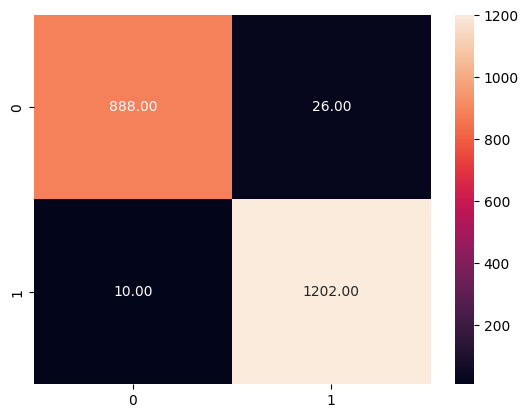

In [57]:
from sklearn import metrics

cm = metrics.confusion_matrix( test_y, test_ds_predicted )
sn.heatmap(cm, annot=True,  fmt='.2f' );

### Using TF-IDF Vectorizer

In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer( analyzer=stemmed_words,
                                   min_df = 5,
                                   max_df = 0.7)
feature_vector = tfidf_vectorizer.fit( train_ds.text )
train_ds_features = tfidf_vectorizer.transform( train_ds.text )
features = list(feature_vector.get_feature_names_out())

In [59]:
from sklearn.naive_bayes import GaussianNB

train_X, test_X, train_y, test_y = train_test_split( train_ds_features,
                                                    train_ds.sentiment,
                                                    test_size = 0.3,
                                                    random_state = 42 )

nb_clf = GaussianNB()
nb_clf.fit( train_X.toarray(), train_y )

GaussianNB()

In [61]:
test_ds_predicted = nb_clf.predict( test_X.toarray() )
print( metrics.classification_report( test_y, test_ds_predicted ) )

              precision    recall  f1-score   support

           0       0.97      0.96      0.97       914
           1       0.97      0.98      0.97      1212

    accuracy                           0.97      2126
   macro avg       0.97      0.97      0.97      2126
weighted avg       0.97      0.97      0.97      2126



### Build a Random Forest Model to find important words

In [66]:
from sklearn.ensemble import RandomForestClassifier

# Adding custom words to the list of stop words
my_stop_words = list(text.ENGLISH_STOP_WORDS.union( ['harry', 'potter', 'code', 'vinci', 'da',
                                                     'harry', 'mountain', 'movie', 'movies', 'impossible',
                                                     'mission', 'mountain', 'brokeback']))

# Create the vectorizer
tfidf_vectorizer = TfidfVectorizer(analyzer=stemmed_words,
                                   min_df = 5,
                                   max_df = 0.7)

feature_vector = tfidf_vectorizer.fit( train_ds.text )
train_ds_features = tfidf_vectorizer.transform( train_ds.text )
features = list(feature_vector.get_feature_names_out())

# Split the dataset into train and test sets
train_X, test_X, train_y, test_y = train_test_split( train_ds_features,
                                                    train_ds.sentiment,
                                                    test_size = 0.3,
                                                    random_state = 42 )
# Build Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators = 200,
                                max_depth = 10,
                                random_state = 42)
rf_clf.fit( train_X.toarray(), train_y )

# Predict on test set and print the classification report
test_ds_predicted = rf_clf.predict( test_X.toarray() )
print( metrics.classification_report( test_y, test_ds_predicted ) )

              precision    recall  f1-score   support

           0       1.00      0.96      0.98       914
           1       0.97      1.00      0.98      1212

    accuracy                           0.98      2126
   macro avg       0.98      0.98      0.98      2126
weighted avg       0.98      0.98      0.98      2126



In [69]:
important_words = pd.DataFrame({ "words": features,
                                 "importance": rf_clf.feature_importances_} )
important_words.sort_values("importance", ascending = False)[0:10]

,words,importance
245,suck,0.191386
166,love,0.162402
115,hate,0.105419
13,awesom,0.092673
244,stupid,0.042443
156,like,0.039816
59,depress,0.022833
252,terribl,0.021583
141,just,0.020856
129,horribl,0.019160
